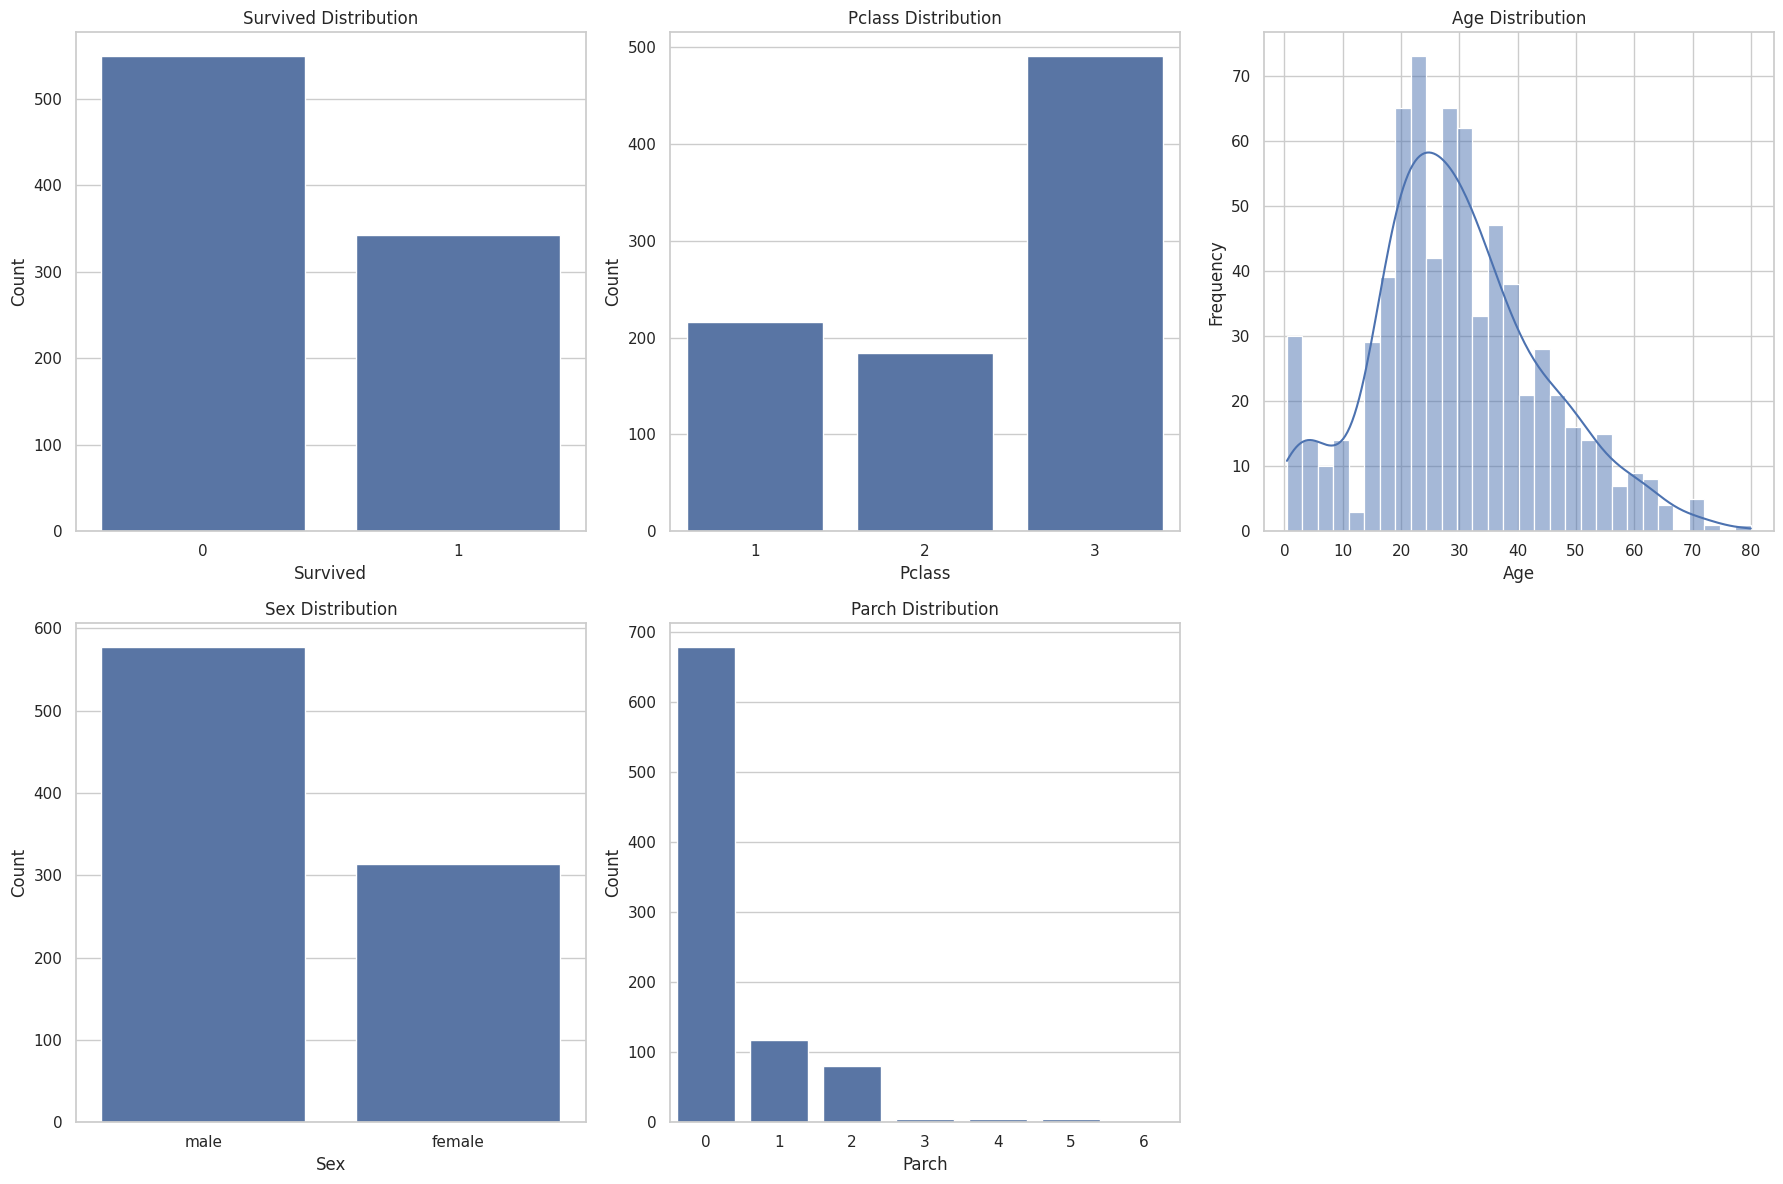

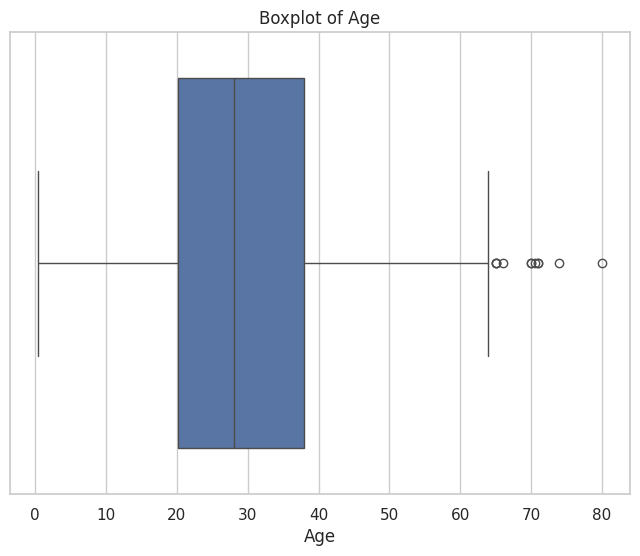

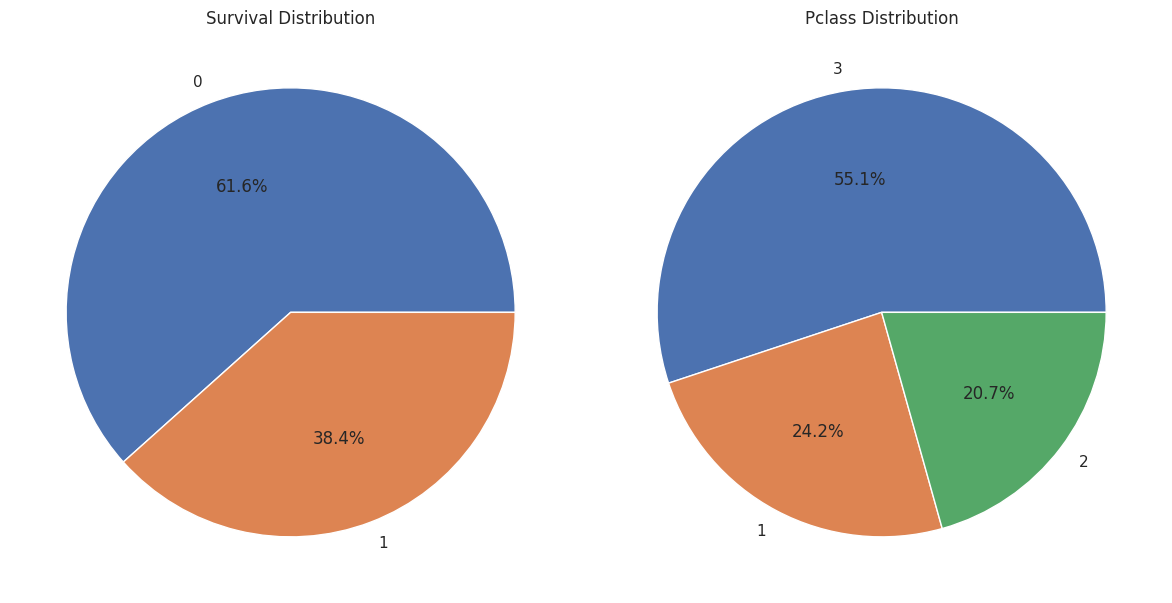

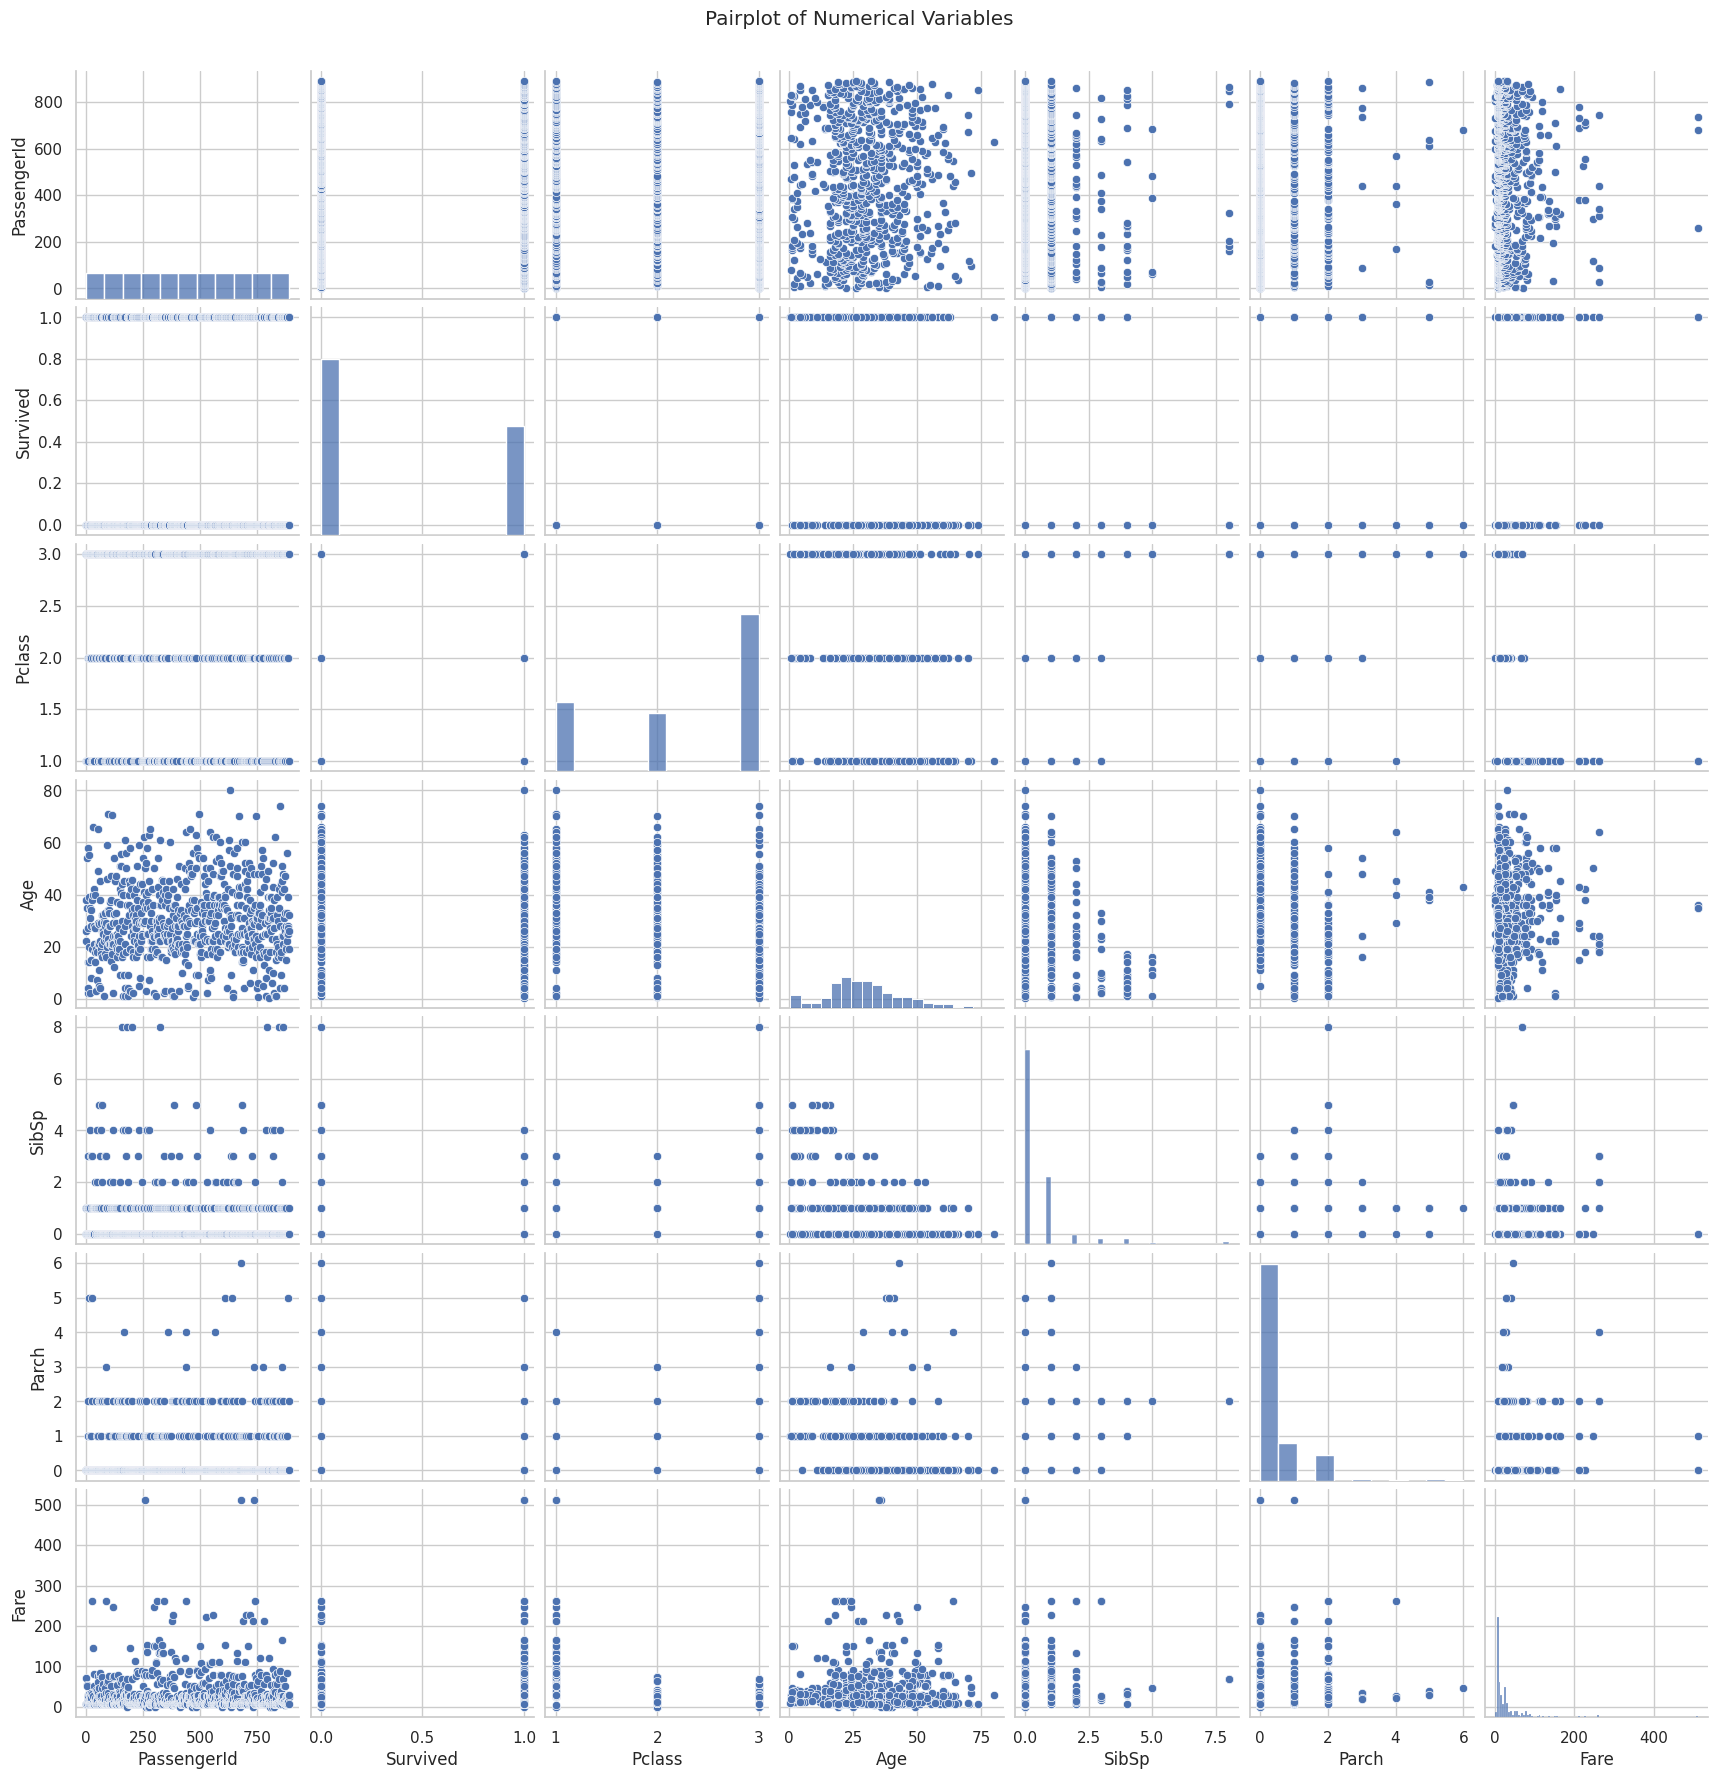

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Чтение данных из файла train.csv
data = pd.read_csv('train (2).csv')

# Визуализация распределения значений признаков
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Survived
sns.countplot(x='Survived', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Survived Distribution')
axes[0, 0].set_xlabel('Survived')
axes[0, 0].set_ylabel('Count')

# Pclass
sns.countplot(x='Pclass', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Pclass Distribution')
axes[0, 1].set_xlabel('Pclass')
axes[0, 1].set_ylabel('Count')

# Age
sns.histplot(data['Age'].dropna(), bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Age Distribution')
axes[0, 2].set_xlabel('Age')
axes[0, 2].set_ylabel('Frequency')

# Sex
sns.countplot(x='Sex', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Sex Distribution')
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Count')

# Parch
sns.countplot(x='Parch', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Parch Distribution')
axes[1, 1].set_xlabel('Parch')
axes[1, 1].set_ylabel('Count')

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

# Построение boxplot для столбца Age
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Age'].dropna())
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

# Построение pie chart для переменных Survived и Pclass
plt.figure(figsize=(12, 6))

# Survived
plt.subplot(1, 2, 1)
survived_counts = data['Survived'].value_counts()
plt.pie(survived_counts, labels=survived_counts.index, autopct='%1.1f%%')
plt.title('Survival Distribution')

# Pclass
plt.subplot(1, 2, 2)
pclass_counts = data['Pclass'].value_counts()
plt.pie(pclass_counts, labels=pclass_counts.index, autopct='%1.1f%%')
plt.title('Pclass Distribution')

plt.tight_layout()
plt.show()

# 6. Построение pairplot для переменных
sns.pairplot(data.select_dtypes(include=['int64', 'float64']))
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

# 7. Построение sunburst plot
sunburst_data = data.groupby(['Pclass', 'Sex']).size().reset_index(name='Count')
fig = px.sunburst(sunburst_data, path=['Pclass', 'Sex'], values='Count',
                  title='Passenger Distribution by Class and Sex')
fig.show()
